In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [34]:
df = pd.read_csv("liver_disease_Dataset.csv", keep_default_na=False)

In [35]:
print(df.head())

   Patient_ID  Age  Gender  Total_Bilirubin  Direct_Bilirubin  \
0           1   79  Female             2.40              3.56   
1           2   41    Male             0.34              0.23   
2           3   51   Other             5.92              3.78   
3           4   63   Other             7.92              2.97   
4           5   83  Female             6.34              2.42   

   ALP_Alkaline_Phosphotase  SGPT_ALT  SGOT_AST  Total_Proteins  Albumin  \
0                       160       143       377            5.82     3.91   
1                        76        18        64            7.72     4.64   
2                       185       107       440            6.77     4.20   
3                       278       187        85            5.19     3.37   
4                       260       624       443            7.04     2.86   

                                      Symptoms Prediction_Result  \
0   Has fever, weakness, and loss of appetite.           Disease   
1               

In [36]:
print(df.shape)

(12000, 14)


In [37]:
print(df.columns)

Index(['Patient_ID', 'Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
       'ALP_Alkaline_Phosphotase', 'SGPT_ALT', 'SGOT_AST', 'Total_Proteins',
       'Albumin', 'Symptoms', 'Prediction_Result', 'Classification_Result',
       'Severity_Score'],
      dtype='object')


In [38]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Patient_ID                12000 non-null  int64  
 1   Age                       12000 non-null  int64  
 2   Gender                    12000 non-null  object 
 3   Total_Bilirubin           12000 non-null  float64
 4   Direct_Bilirubin          12000 non-null  float64
 5   ALP_Alkaline_Phosphotase  12000 non-null  int64  
 6   SGPT_ALT                  12000 non-null  int64  
 7   SGOT_AST                  12000 non-null  int64  
 8   Total_Proteins            12000 non-null  float64
 9   Albumin                   12000 non-null  float64
 10  Symptoms                  12000 non-null  object 
 11  Prediction_Result         12000 non-null  object 
 12  Classification_Result     12000 non-null  object 
 13  Severity_Score            12000 non-null  float64
dtypes: flo

In [39]:
print(df.isnull().sum())

Patient_ID                  0
Age                         0
Gender                      0
Total_Bilirubin             0
Direct_Bilirubin            0
ALP_Alkaline_Phosphotase    0
SGPT_ALT                    0
SGOT_AST                    0
Total_Proteins              0
Albumin                     0
Symptoms                    0
Prediction_Result           0
Classification_Result       0
Severity_Score              0
dtype: int64


In [40]:
print(df["Classification_Result"].unique())

['Hepatitis' 'None' 'Liver Cirrhosis' 'Fatty Liver']


In [41]:
print(df.describe())

        Patient_ID           Age  Total_Bilirubin  Direct_Bilirubin  \
count  12000.00000  12000.000000     12000.000000      12000.000000   
mean    6000.50000     51.595917         2.702461          1.272482   
std     3464.24595     19.565587         2.370924          1.227022   
min        1.00000     18.000000         0.200000          0.100000   
25%     3000.75000     35.000000         1.030000          0.420000   
50%     6000.50000     52.000000         1.740000          0.690000   
75%     9000.25000     69.000000         3.930000          2.000000   
max    12000.00000     85.000000        10.000000          5.000000   

       ALP_Alkaline_Phosphotase      SGPT_ALT      SGOT_AST  Total_Proteins  \
count              12000.000000  12000.000000  12000.000000    12000.000000   
mean                 175.501667    174.627833    166.895083        6.923912   
std                   78.775102    229.434105    208.614850        0.734841   
min                   70.000000     10.00000

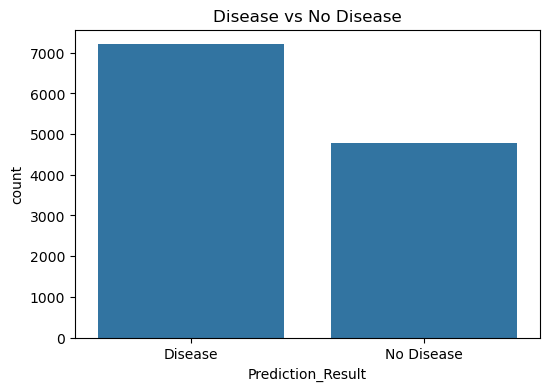

In [42]:
plt.figure(figsize=(6,4))
sns.countplot(x='Prediction_Result', data=df)
plt.title("Disease vs No Disease")
plt.show()

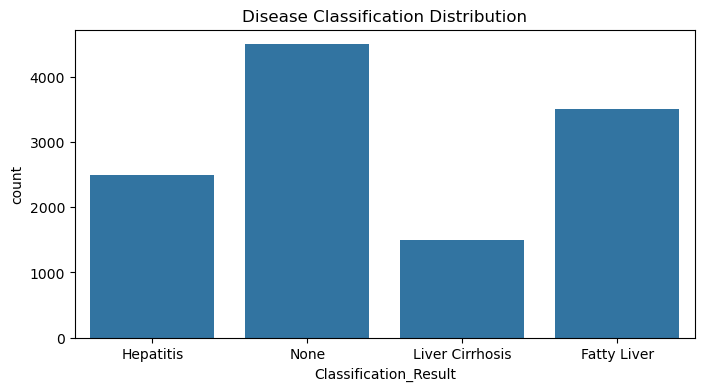

In [43]:
plt.figure(figsize=(8,4))
sns.countplot(x='Classification_Result', data=df)
plt.title("Disease Classification Distribution")
plt.show()

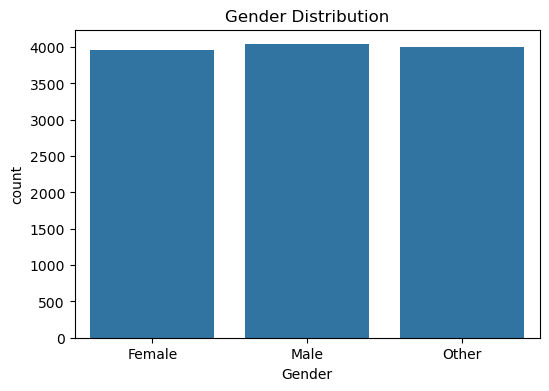

In [44]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

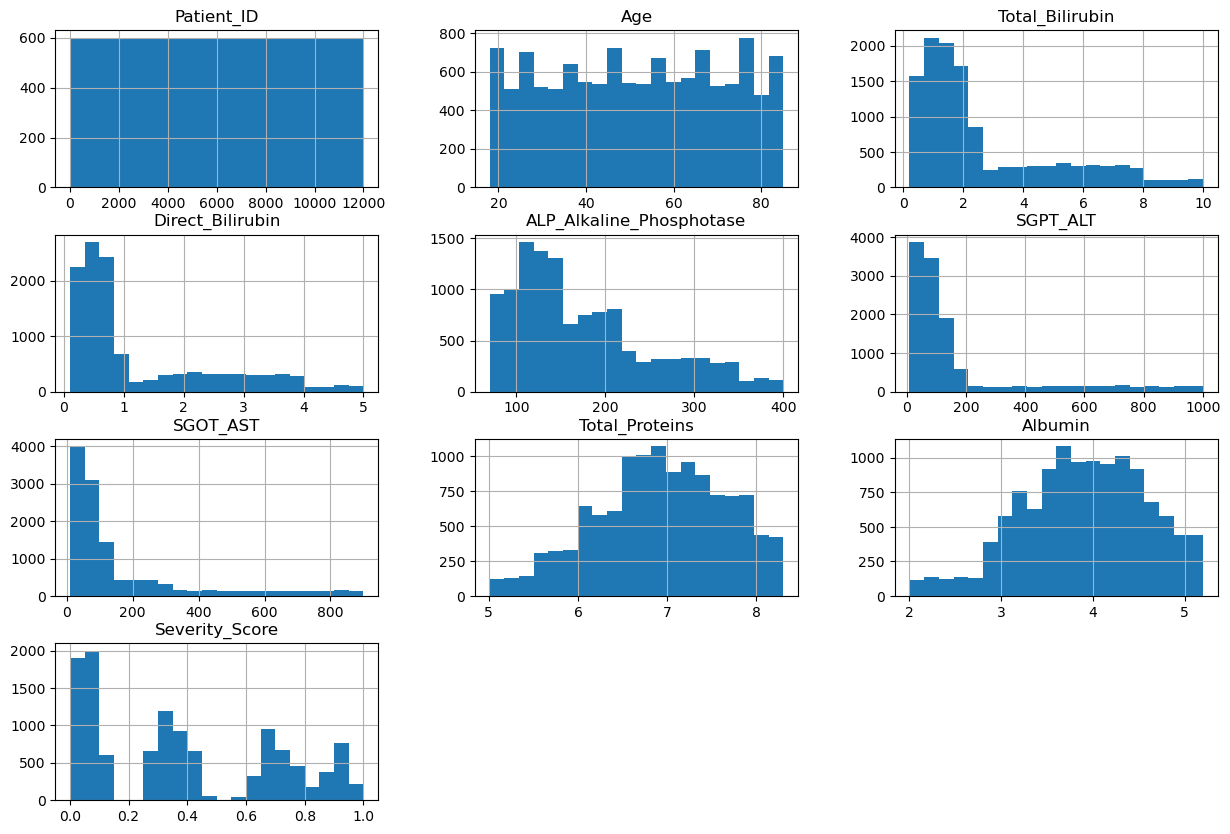

In [45]:
df.hist(figsize=(15,10), bins=20)
plt.show()

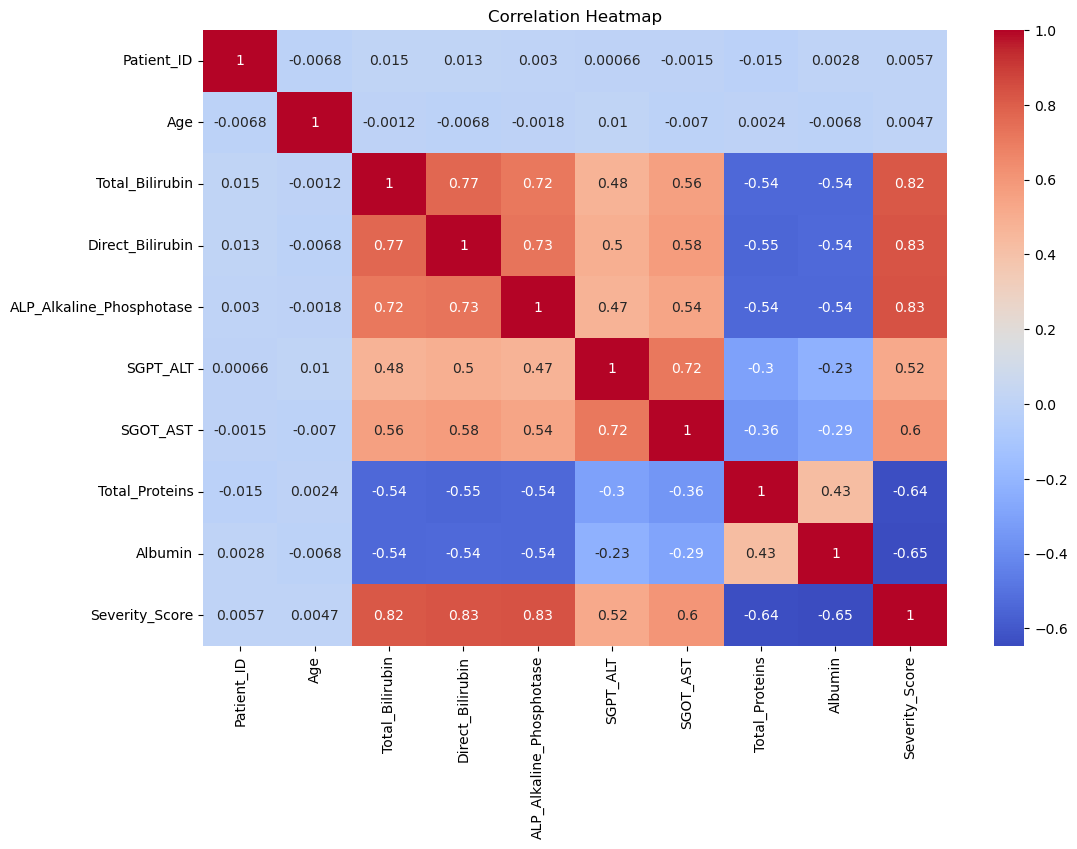

In [46]:
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include=['int64','float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


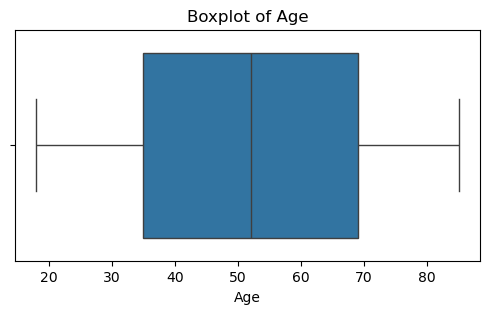

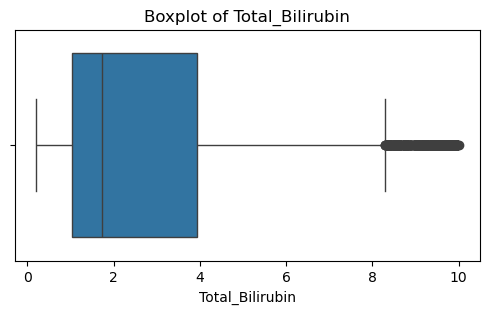

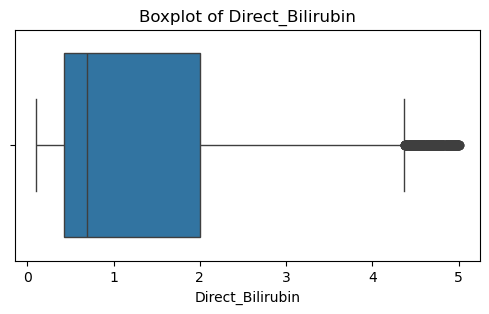

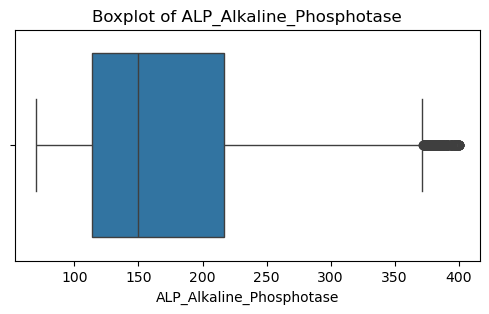

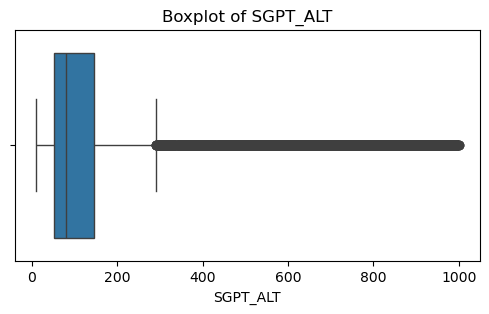

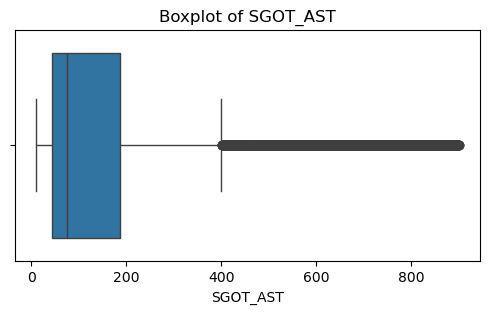

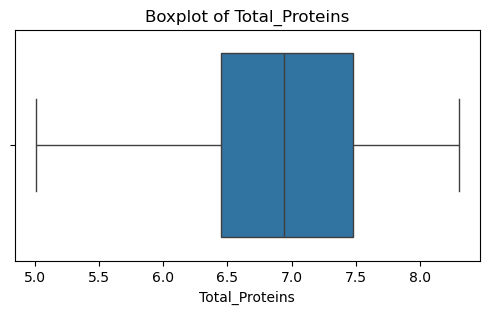

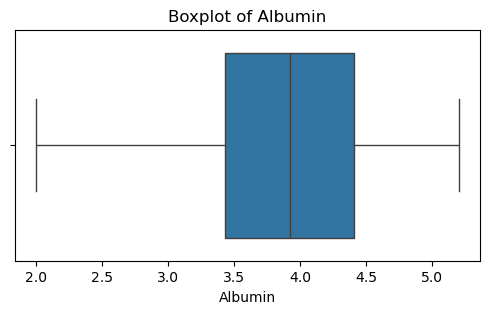

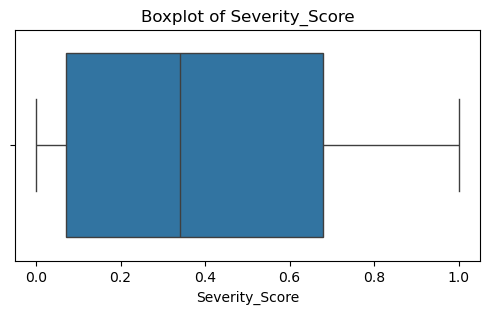

In [47]:
numerical_cols = [
    'Age',
    'Total_Bilirubin',
    'Direct_Bilirubin',
    'ALP_Alkaline_Phosphotase',
    'SGPT_ALT',
    'SGOT_AST',
    'Total_Proteins',
    'Albumin',
    'Severity_Score'
]

for col in numerical_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

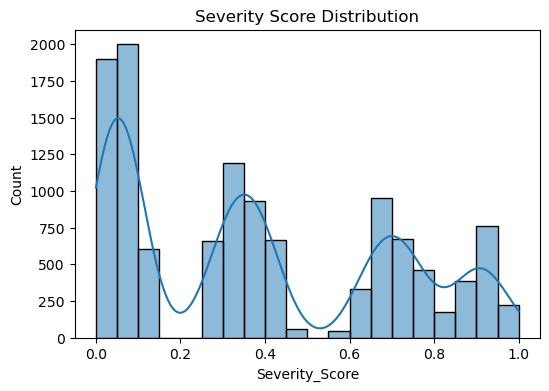

In [48]:
plt.figure(figsize=(6,4))
sns.histplot(df["Severity_Score"], bins=20, kde=True)
plt.title("Severity Score Distribution")
plt.show()

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

le_gender = LabelEncoder()
df["Gender_Encoded"] = le_gender.fit_transform(df["Gender"])

X1 = df[[
    "Age",
    "Total_Bilirubin",
    "Direct_Bilirubin",
    "ALP_Alkaline_Phosphotase",
    "SGPT_ALT",
    "SGOT_AST",
    "Total_Proteins",
    "Albumin"
]]


le_pred = LabelEncoder()
y1 = le_pred.fit_transform(df["Prediction_Result"])

X_train, X_test, y_train, y_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

model1 = RandomForestClassifier(max_depth=5, n_estimators=50)
model1.fit(X_train, y_train)

y_pred = model1.predict(X_test)

print("Prediction Model Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Prediction Model Accuracy: 0.9016666666666666
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      1414
           1       0.89      0.87      0.88       986

    accuracy                           0.90      2400
   macro avg       0.90      0.90      0.90      2400
weighted avg       0.90      0.90      0.90      2400



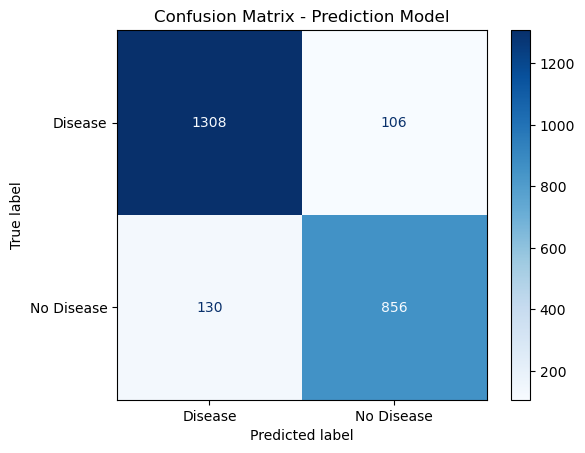

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm1 = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=le_pred.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Prediction Model")
plt.show()

In [51]:
le_class = LabelEncoder()
y2 = le_class.fit_transform(df["Classification_Result"])

X_train2, X_test2, y_train2, y_test2 = train_test_split(X1, y2, test_size=0.2, random_state=42)

model2 = RandomForestClassifier()
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)

print("Classification Model Accuracy:", accuracy_score(y_test2, y_pred2))
print(classification_report(y_test2, y_pred2))

Classification Model Accuracy: 0.9775
              precision    recall  f1-score   support

           0       0.98      0.94      0.96       670
           1       1.00      0.99      0.99       524
           2       0.98      1.00      0.99       290
           3       0.96      0.99      0.97       916

    accuracy                           0.98      2400
   macro avg       0.98      0.98      0.98      2400
weighted avg       0.98      0.98      0.98      2400



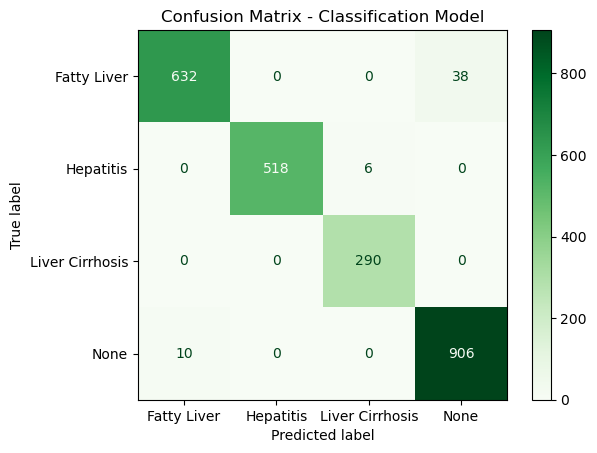

In [52]:
cm2 = confusion_matrix(y_test2, y_pred2)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm2,
    display_labels=le_class.classes_
)

disp.plot(cmap="Greens")
plt.title("Confusion Matrix - Classification Model")
plt.show()

In [53]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X3 = df["Symptoms"]
y3 = df["Severity_Score"]

tfidf = TfidfVectorizer(max_features=500)
X3_tfidf = tfidf.fit_transform(X3)

X_train3, X_test3, y_train3, y_test3 = train_test_split(X3_tfidf, y3, test_size=0.2, random_state=42)

model3 = LinearRegression()
model3.fit(X_train3, y_train3)

y_pred3 = model3.predict(X_test3)

print("Severity Model MSE:", mean_squared_error(y_test3, y_pred3))
print("Severity Model R2 Score:", r2_score(y_test3, y_pred3))

Severity Model MSE: 0.0008270865498495859
Severity Model R2 Score: 0.9916877947647026


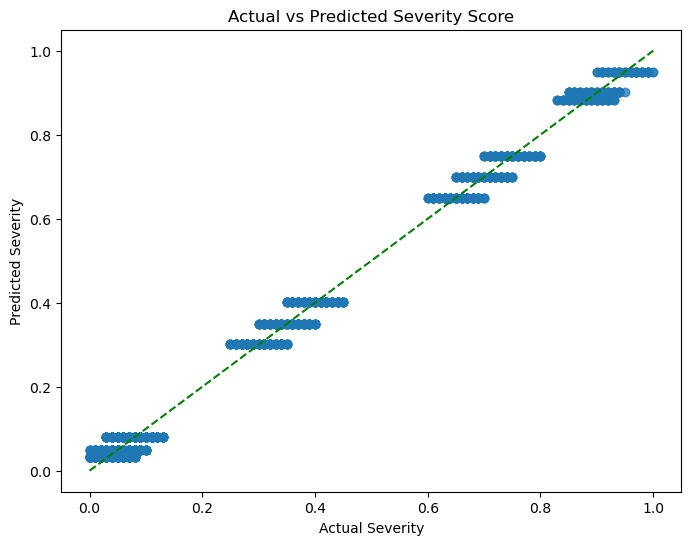

In [54]:
plt.figure(figsize=(8,6))
plt.scatter(y_test3, y_pred3, alpha=0.5)
plt.plot([0,1], [0,1], 'g--')
plt.xlabel("Actual Severity")
plt.ylabel("Predicted Severity")
plt.title("Actual vs Predicted Severity Score")
plt.show()

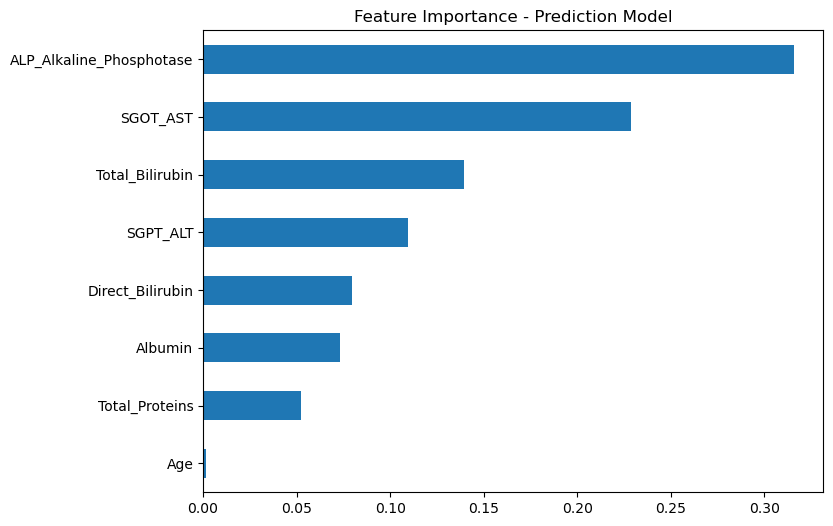

In [55]:
importance = model1.feature_importances_
features = X1.columns

feat_imp = pd.Series(importance, index=features)
feat_imp.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance - Prediction Model")
plt.show()

In [56]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model1, X1, y1, cv=5)
print("Cross-validation accuracy:", scores.mean())

Cross-validation accuracy: 0.89975


In [57]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, HistGradientBoostingClassifier

In [58]:
le_pred = LabelEncoder()
y1 = le_pred.fit_transform(df["Prediction_Result"])

In [59]:
# Encode gender if not already done
le_gender = LabelEncoder()
df["Gender_Encoded"] = le_gender.fit_transform(df["Gender"])

# Feature engineering for boosting
df["Globulin"] = df["Total_Proteins"] - df["Albumin"]

df["Albumin_Globulin_Ratio"] = df["Albumin"] / (df["Globulin"] + 1e-6)

df["Direct_Total_Bilirubin_Ratio"] = df["Direct_Bilirubin"] / (df["Total_Bilirubin"] + 1e-6)

df["AST_ALT_Ratio"] = df["SGOT_AST"] / (df["SGPT_ALT"] + 1e-6)

df["Enzyme_Total"] = (
    df["ALP_Alkaline_Phosphotase"] +
    df["SGPT_ALT"] +
    df["SGOT_AST"]
)

X_boost = df[[
    "Age",
    "Gender_Encoded",
    "Total_Bilirubin",
    "Direct_Bilirubin",
    "ALP_Alkaline_Phosphotase",
    "SGPT_ALT",
    "SGOT_AST",
    "Total_Proteins",
    "Albumin",
    "Globulin",
    "Albumin_Globulin_Ratio",
    "Direct_Total_Bilirubin_Ratio",
    "AST_ALT_Ratio",
    "Enzyme_Total"
]]

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X_boost,
    y1,
    test_size=0.2,
    random_state=42,
    stratify=y1
)

In [61]:
boost_models = {
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ),

    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=42
    )
}

best_model = None
best_accuracy = 0
best_model_name = ""

for name, model in boost_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print("\n==============================")
    print(name)
    print("==============================")
    print(f"Accuracy: {acc:.10f}")
    print(classification_report(y_test, y_pred, digits=6))

    if acc > best_accuracy:
        best_accuracy = acc
        best_model = model
        best_model_name = name

print("\nBest Boosting Model Before Tuning:", best_model_name)
print(f"Best Boosting Accuracy Before Tuning: {best_accuracy:.10f}")


Gradient Boosting
Accuracy: 0.9004166667
              precision    recall  f1-score   support

           0   0.906081  0.930604  0.918179      1441
           1   0.891304  0.855057  0.872805       959

    accuracy                       0.900417      2400
   macro avg   0.898693  0.892831  0.895492      2400
weighted avg   0.900177  0.900417  0.900048      2400


AdaBoost
Accuracy: 0.8658333333
              precision    recall  f1-score   support

           0   0.887197  0.889660  0.888427      1441
           1   0.833508  0.830031  0.831766       959

    accuracy                       0.865833      2400
   macro avg   0.860353  0.859846  0.860096      2400
weighted avg   0.865744  0.865833  0.865786      2400


Hist Gradient Boosting
Accuracy: 0.9016666667
              precision    recall  f1-score   support

           0   0.908475  0.929910  0.919067      1441
           1   0.890811  0.859228  0.874735       959

    accuracy                       0.901667      2400
   mac

In [62]:
gb = GradientBoostingClassifier(random_state=42)

param_grid_gb = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.07, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_leaf": [1, 2, 5],
    "subsample": [0.8, 0.9, 1.0]
}

search_gb = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_grid_gb,
    n_iter=15,
    scoring="accuracy",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search_gb.fit(X_train, y_train)

best_gb = search_gb.best_estimator_

y_pred_gb = best_gb.predict(X_test)

gb_acc = accuracy_score(y_test, y_pred_gb)

print("\n==============================")
print("Tuned Gradient Boosting")
print("==============================")
print("Best Parameters:")
print(search_gb.best_params_)

print(f"Tuned Gradient Boosting Accuracy: {gb_acc:.10f}")
print(classification_report(y_test, y_pred_gb, digits=6))

if gb_acc > best_accuracy:
    best_accuracy = gb_acc
    best_model = best_gb
    best_model_name = "Tuned Gradient Boosting"

print("\nCurrent Best Boosting Model:", best_model_name)
print(f"Current Best Boosting Accuracy: {best_accuracy:.10f}")

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Tuned Gradient Boosting
Best Parameters:
{'subsample': 0.8, 'n_estimators': 100, 'min_samples_leaf': 2, 'max_depth': 4, 'learning_rate': 0.05}
Tuned Gradient Boosting Accuracy: 0.8991666667
              precision    recall  f1-score   support

           0   0.905341  0.929216  0.917123      1441
           1   0.889251  0.854015  0.871277       959

    accuracy                       0.899167      2400
   macro avg   0.897296  0.891615  0.894200      2400
weighted avg   0.898912  0.899167  0.898804      2400


Current Best Boosting Model: Hist Gradient Boosting
Current Best Boosting Accuracy: 0.9016666667


In [63]:
hgb = HistGradientBoostingClassifier(random_state=42)

param_grid_hgb = {
    "learning_rate": [0.03, 0.05, 0.07, 0.1],
    "max_iter": [100, 200, 300],
    "max_leaf_nodes": [15, 31, 63],
    "max_depth": [3, 5, 7, None],
    "min_samples_leaf": [10, 20, 30],
    "l2_regularization": [0.0, 0.01, 0.1]
}

search_hgb = RandomizedSearchCV(
    estimator=hgb,
    param_distributions=param_grid_hgb,
    n_iter=20,
    scoring="accuracy",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search_hgb.fit(X_train, y_train)

best_hgb = search_hgb.best_estimator_

y_pred_hgb = best_hgb.predict(X_test)

hgb_acc = accuracy_score(y_test, y_pred_hgb)

print("\n==============================")
print("Tuned Hist Gradient Boosting")
print("==============================")
print("Best Parameters:")
print(search_hgb.best_params_)

print(f"Tuned Hist Gradient Boosting Accuracy: {hgb_acc:.10f}")
print(classification_report(y_test, y_pred_hgb, digits=6))

if hgb_acc > best_accuracy:
    best_accuracy = hgb_acc
    best_model = best_hgb
    best_model_name = "Tuned Hist Gradient Boosting"

print("\nCurrent Best Boosting Model:", best_model_name)
print(f"Current Best Boosting Accuracy: {best_accuracy:.10f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Tuned Hist Gradient Boosting
Best Parameters:
{'min_samples_leaf': 10, 'max_leaf_nodes': 31, 'max_iter': 100, 'max_depth': 7, 'learning_rate': 0.05, 'l2_regularization': 0.1}
Tuned Hist Gradient Boosting Accuracy: 0.9008333333
              precision    recall  f1-score   support

           0   0.907244  0.929910  0.918437      1441
           1   0.890574  0.857143  0.873539       959

    accuracy                       0.900833      2400
   macro avg   0.898909  0.893526  0.895988      2400
weighted avg   0.900583  0.900833  0.900497      2400


Current Best Boosting Model: Hist Gradient Boosting
Current Best Boosting Accuracy: 0.9016666667


In [68]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

xgb_acc = accuracy_score(y_test, y_pred_xgb)

print("\n==============================")
print("XGBoost Classifier")
print("==============================")
print(f"XGBoost Accuracy: {xgb_acc:.10f}")
print(classification_report(y_test, y_pred_xgb, digits=6))

if xgb_acc >= best_accuracy:
    best_accuracy = xgb_acc
    best_model = xgb
    best_model_name = "XGBoost Classifier"

print("\nCurrent Best Boosting Model:", best_model_name)
print(f"Current Best Boosting Accuracy: {best_accuracy:.10f}")


XGBoost Classifier
XGBoost Accuracy: 0.9004166667
              precision    recall  f1-score   support

           0   0.906081  0.930604  0.918179      1441
           1   0.891304  0.855057  0.872805       959

    accuracy                       0.900417      2400
   macro avg   0.898693  0.892831  0.895492      2400
weighted avg   0.900177  0.900417  0.900048      2400


Current Best Boosting Model: Hist Gradient Boosting
Current Best Boosting Accuracy: 0.9016666667


In [69]:
try:
    from xgboost import XGBClassifier

    xgb_tune = XGBClassifier(
        eval_metric="logloss",
        random_state=42
    )

    param_grid_xgb = {
        "n_estimators": [300, 500, 700],
        "learning_rate": [0.01, 0.03, 0.05, 0.07],
        "max_depth": [3, 4, 5],
        "subsample": [0.8, 0.9, 1.0],
        "colsample_bytree": [0.8, 0.9, 1.0],
        "gamma": [0, 0.1, 0.2],
        "reg_lambda": [1, 2, 5]
    }

    search_xgb = RandomizedSearchCV(
        estimator=xgb_tune,
        param_distributions=param_grid_xgb,
        n_iter=25,
        scoring="accuracy",
        cv=3,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

    search_xgb.fit(X_train, y_train)

    best_xgb = search_xgb.best_estimator_

    y_pred_xgb_tuned = best_xgb.predict(X_test)

    xgb_tuned_acc = accuracy_score(y_test, y_pred_xgb_tuned)

    print("\n==============================")
    print("Tuned XGBoost")
    print("==============================")
    print("Best Parameters:")
    print(search_xgb.best_params_)

    print(f"Tuned XGBoost Accuracy: {xgb_tuned_acc:.10f}")
    print(classification_report(y_test, y_pred_xgb_tuned, digits=6))

    if xgb_tuned_acc > best_accuracy:
        best_accuracy = xgb_tuned_acc
        best_model = best_xgb
        best_model_name = "Tuned XGBoost"

    print("\nCurrent Best Boosting Model:", best_model_name)
    print(f"Current Best Boosting Accuracy: {best_accuracy:.10f}")

except ImportError:
    print("XGBoost is not installed. Run: pip install xgboost")

Fitting 3 folds for each of 25 candidates, totalling 75 fits

Tuned XGBoost
Best Parameters:
{'subsample': 0.8, 'reg_lambda': 1, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.03, 'gamma': 0.1, 'colsample_bytree': 0.8}
Tuned XGBoost Accuracy: 0.9016666667
              precision    recall  f1-score   support

           0   0.907370  0.931298  0.919178      1441
           1   0.892508  0.857143  0.874468       959

    accuracy                       0.901667      2400
   macro avg   0.899939  0.894220  0.896823      2400
weighted avg   0.901431  0.901667  0.901313      2400


Current Best Boosting Model: Hist Gradient Boosting
Current Best Boosting Accuracy: 0.9016666667


In [70]:
if hasattr(best_model, "predict_proba"):

    y_prob = best_model.predict_proba(X_test)[:, 1]

    best_threshold = 0.5
    best_threshold_acc = 0

    for threshold in np.arange(0.30, 0.71, 0.01):
        y_pred_threshold = (y_prob >= threshold).astype(int)

        acc = accuracy_score(y_test, y_pred_threshold)

        if acc > best_threshold_acc:
            best_threshold_acc = acc
            best_threshold = threshold

    print("\n==============================")
    print("Threshold Tuning")
    print("==============================")
    print(f"Best Threshold: {best_threshold:.2f}")
    print(f"Best Threshold Accuracy: {best_threshold_acc:.10f}")

    y_pred_final_boost = (y_prob >= best_threshold).astype(int)

    print(classification_report(y_test, y_pred_final_boost, digits=6))

    if best_threshold_acc > best_accuracy:
        best_accuracy = best_threshold_acc
        best_model_name = best_model_name + " with Threshold Tuning"

else:
    print("This model does not support predict_proba.")


Threshold Tuning
Best Threshold: 0.46
Best Threshold Accuracy: 0.9020833333
              precision    recall  f1-score   support

           0   0.909647  0.929216  0.919327      1441
           1   0.890086  0.861314  0.875464       959

    accuracy                       0.902083      2400
   macro avg   0.899866  0.895265  0.897395      2400
weighted avg   0.901831  0.902083  0.901800      2400



In [71]:
print("\n==============================")
print("FINAL BOOSTING RESULT")
print("==============================")
print("Final Best Boosting Model:", best_model_name)
print(f"Final Best Boosting Accuracy: {best_accuracy:.10f}")


FINAL BOOSTING RESULT
Final Best Boosting Model: Hist Gradient Boosting with Threshold Tuning
Final Best Boosting Accuracy: 0.9020833333


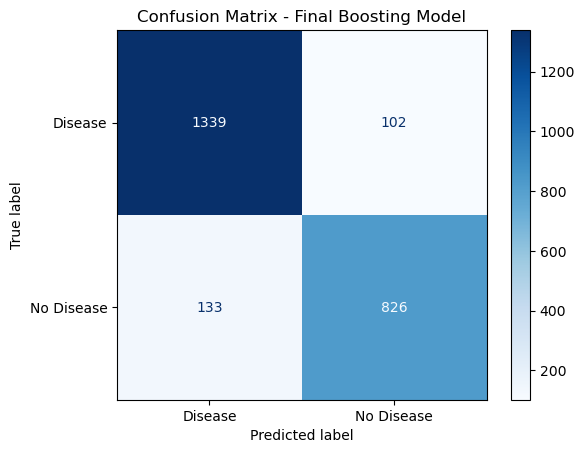

In [72]:
if hasattr(best_model, "predict_proba") and "Threshold Tuning" in best_model_name:
    y_prob = best_model.predict_proba(X_test)[:, 1]
    y_pred_final = (y_prob >= best_threshold).astype(int)
else:
    y_pred_final = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_final)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le_pred.classes_
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Final Boosting Model")
plt.show()

In [73]:

# Target for classification model
le_class = LabelEncoder()
y2 = le_class.fit_transform(df["Classification_Result"])

# Train-test split
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X1, y2, test_size=0.2, random_state=42,stratify=y2
)

classification_boost_models = {
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ),

    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=42
    )
}

best_class_model = None
best_class_accuracy = 0
best_class_model_name = ""

for name, model in classification_boost_models.items():
    model.fit(X_train2, y_train2)

    y_pred2 = model.predict(X_test2)

    acc = accuracy_score(y_test2, y_pred2)

    print("\n==============================")
    print(name)
    print("==============================")
    print(f"Classification Accuracy: {acc:.10f}")
    print(classification_report(y_test2, y_pred2, digits=6,zero_division=0))

    if acc > best_class_accuracy:
        best_class_accuracy = acc
        best_class_model = model
        best_class_model_name = name

print("\nBest Classification Boosting Model:", best_class_model_name)
print(f"Best Classification Boosting Accuracy: {best_class_accuracy:.10f}")


Gradient Boosting
Classification Accuracy: 0.9787500000
              precision    recall  f1-score   support

           0   0.991058  0.950000  0.970095       700
           1   1.000000  0.976000  0.987854       500
           2   0.967742  1.000000  0.983607       300
           3   0.962406  0.995556  0.978700       900

    accuracy                       0.978750      2400
   macro avg   0.980302  0.980389  0.980064      2400
weighted avg   0.979262  0.978750  0.978711      2400


AdaBoost
Classification Accuracy: 0.5858333333
              precision    recall  f1-score   support

           0   0.875000  0.010000  0.019774       700
           1   0.624531  0.998000  0.768283       500
           2   0.000000  0.000000  0.000000       300
           3   0.564972  1.000000  0.722022       900

    accuracy                       0.585833      2400
   macro avg   0.516126  0.502000  0.377520      2400
weighted avg   0.597183  0.585833  0.436585      2400


Hist Gradient Boosting
C

In [74]:
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor, HistGradientBoostingRegressor

# Input and target
X3 = df["Symptoms"]
y3 = df["Severity_Score"]

# Convert symptoms text into numbers
tfidf = TfidfVectorizer(max_features=500)
X3_tfidf = tfidf.fit_transform(X3)

# Train-test split
X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X3_tfidf, y3, test_size=0.2, random_state=42
)

# Linear Regression baseline
model3 = LinearRegression()
model3.fit(X_train3, y_train3)

y_pred3_linear = model3.predict(X_test3)
y_pred3_linear = np.clip(y_pred3_linear, 0, 1)

linear_mse = mean_squared_error(y_test3, y_pred3_linear)
linear_r2 = r2_score(y_test3, y_pred3_linear)

print("\n==============================")
print("Linear Regression Severity Model")
print("==============================")
print(f"MSE: {linear_mse:.10f}")
print(f"R2 Score: {linear_r2:.10f}")

# Convert sparse matrix to dense for boosting regressors
X_train3_dense = X_train3.toarray()
X_test3_dense = X_test3.toarray()

severity_boost_models = {
    "Gradient Boosting Regressor": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "AdaBoost Regressor": AdaBoostRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ),

    "Hist Gradient Boosting Regressor": HistGradientBoostingRegressor(
        max_iter=200,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=42
    )
}

best_severity_model = None
best_severity_r2 = -999
best_severity_model_name = ""

for name, model in severity_boost_models.items():
    model.fit(X_train3_dense, y_train3)

    y_pred3_boost = model.predict(X_test3_dense)
    y_pred3_boost = np.clip(y_pred3_boost, 0, 1)

    mse = mean_squared_error(y_test3, y_pred3_boost)
    r2 = r2_score(y_test3, y_pred3_boost)

    print("\n==============================")
    print(name)
    print("==============================")
    print(f"MSE: {mse:.10f}")
    print(f"R2 Score: {r2:.10f}")

    if r2 > best_severity_r2:
        best_severity_r2 = r2
        best_severity_model = model
        best_severity_model_name = name

print("\nBest Severity Boosting Model:", best_severity_model_name)
print(f"Best Severity Boosting R2 Score: {best_severity_r2:.10f}")


Linear Regression Severity Model
MSE: 0.0008270865
R2 Score: 0.9916877948

Gradient Boosting Regressor
MSE: 0.0008270656
R2 Score: 0.9916880048

AdaBoost Regressor
MSE: 0.0014040350
R2 Score: 0.9858894731

Hist Gradient Boosting Regressor
MSE: 0.0008270796
R2 Score: 0.9916878644

Best Severity Boosting Model: Gradient Boosting Regressor
Best Severity Boosting R2 Score: 0.9916880048
